In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


dataset visualization

In [32]:
BASE_DIR = "/content/drive/MyDrive/TASK-ERAU/C-MAPSS"

FD = "FD001"
DATA_DIR = f"{BASE_DIR}/{FD}"

train_path = f"{DATA_DIR}/train_{FD}.txt"
test_path  = f"{DATA_DIR}/test_{FD}.txt"
rul_path   = f"{DATA_DIR}/RUL_{FD}.txt"

print(train_path)
print(test_path)
print(rul_path)

/content/drive/MyDrive/TASK-ERAU/C-MAPSS/FD001/train_FD001.txt
/content/drive/MyDrive/TASK-ERAU/C-MAPSS/FD001/test_FD001.txt
/content/drive/MyDrive/TASK-ERAU/C-MAPSS/FD001/RUL_FD001.txt


In [33]:
import pandas as pd
import numpy as np

columns = (
    ["unit", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"s{i}" for i in range(1, 22)]
)

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=columns)
test_df  = pd.read_csv(test_path, sep=r"\s+", header=None, names=columns)
rul_df   = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)

train_df.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [35]:
print("Number of training engines:", train_df["unit"].nunique())
print("Number of test engines:", test_df["unit"].nunique())

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nFirst 5 rows:")
display(train_df.head())

print("\nLast 5 rows:")
display(train_df.tail())

Number of training engines: 100
Number of test engines: 100

Train columns:
['unit', 'cycle', 'setting_1', 'setting_2', 'setting_3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']

First 5 rows:


,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044



Last 5 rows:


,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


Add RUL label to training data

In [36]:
train_df["max_cycle"] = train_df.groupby("unit")["cycle"].transform("max")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]

display(train_df[["unit", "cycle", "max_cycle", "RUL"]].head())
display(train_df[["unit", "cycle", "max_cycle", "RUL"]].tail())

,unit,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


,unit,cycle,max_cycle,RUL
20626,100,196,200,4
20627,100,197,200,3
20628,100,198,200,2
20629,100,199,200,1
20630,100,200,200,0


Add early fault label

In [ ]:
FAULT_THRESHOLD = 30

train_df["early_fault"] = (train_df["RUL"] <= FAULT_THRESHOLD).astype(int)

print(train_df["early_fault"].value_counts())
display(train_df[["unit", "cycle", "RUL", "early_fault"]].head())
display(train_df[["unit", "cycle", "RUL", "early_fault"]].tail())

early_fault
0    17531
1     3100
Name: count, dtype: int64


,unit,cycle,RUL,early_fault
0,1,1,191,0
1,1,2,190,0
2,1,3,189,0
3,1,4,188,0
4,1,5,187,0


,unit,cycle,RUL,early_fault
20626,100,196,4,1
20627,100,197,3,1
20628,100,198,2,1
20629,100,199,1,1
20630,100,200,0,1


visualize FD001

Visualization 1: Number of cycles per engine

This shows how long each engine lived before failure.

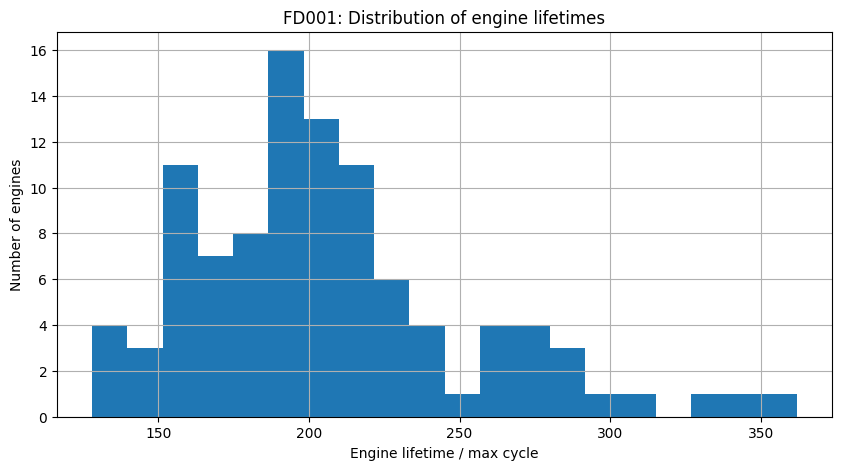

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

engine_life = train_df.groupby("unit")["cycle"].max()

plt.figure(figsize=(10, 5))
plt.hist(engine_life, bins=20)
plt.xlabel("Engine lifetime / max cycle")
plt.ylabel("Number of engines")
plt.title("FD001: Distribution of engine lifetimes")
plt.grid(True)
plt.show()

print(engine_life.describe())

Visualization 2: RUL decreases over time

RUL for a few engines.

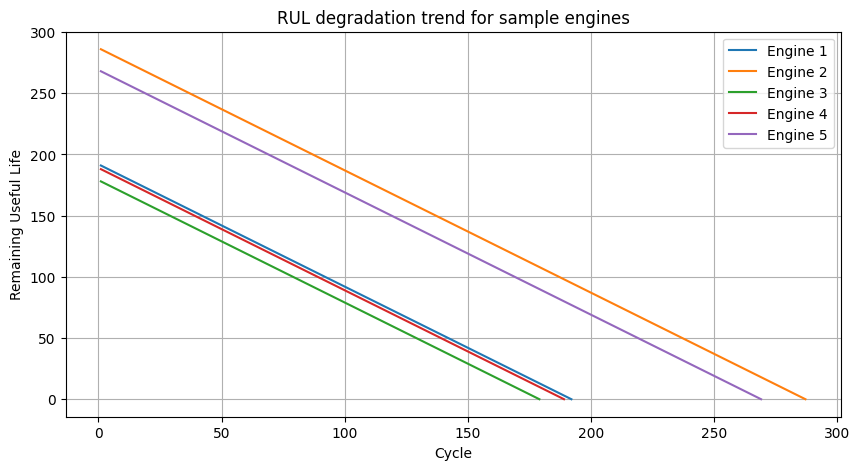

In [40]:
plt.figure(figsize=(10, 5))
for engine_id in [1, 2, 3, 4, 5]:
  temp = train_df[train_df["unit"] == engine_id]
  plt.plot(temp["cycle"], temp["RUL"], label=f"Engine {engine_id}")

plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life")
plt.title("RUL degradation trend for sample engines")
plt.legend()
plt.grid(True)
plt.show()

Visualization 3: Sensor trend for one engine

Now look at how sensors change as the engine gets closer to failure.

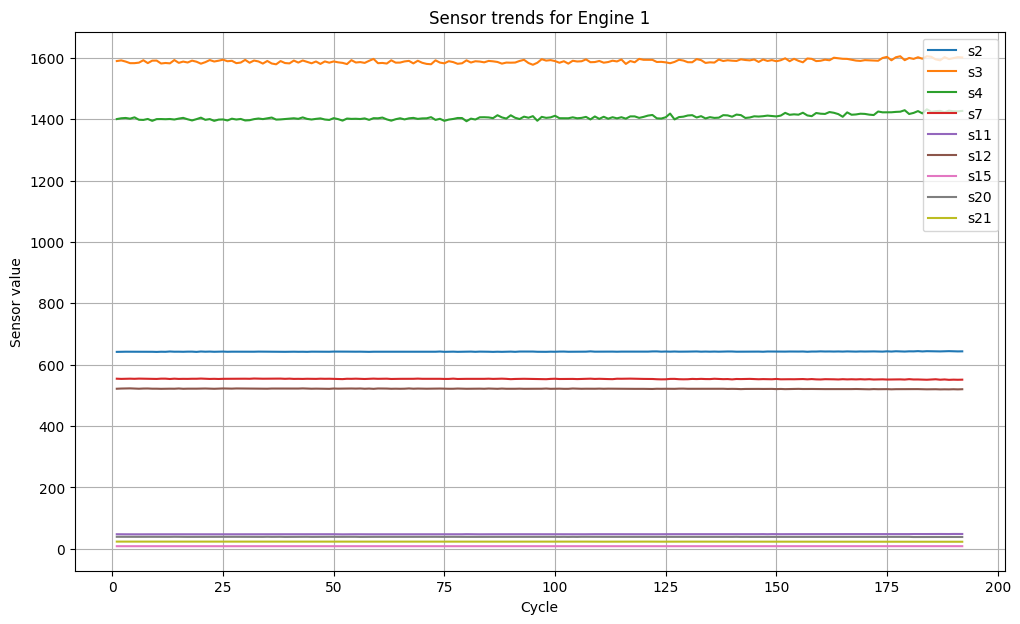

In [ ]:
engine_id = 1
engine_data = train_df[train_df["unit"] == engine_id]

sensors_to_plot = ["s2", "s3", "s4", "s7", "s11", "s12", "s15", "s20", "s21"]

plt.figure(figsize=(12, 7))

for sensor in sensors_to_plot:
    plt.plot(engine_data["cycle"], engine_data[sensor], label=sensor)

plt.xlabel("Cycle")
plt.ylabel("Sensor value")
plt.title(f"Sensor trends for Engine {engine_id}")
plt.legend()
plt.grid(True)
plt.show()

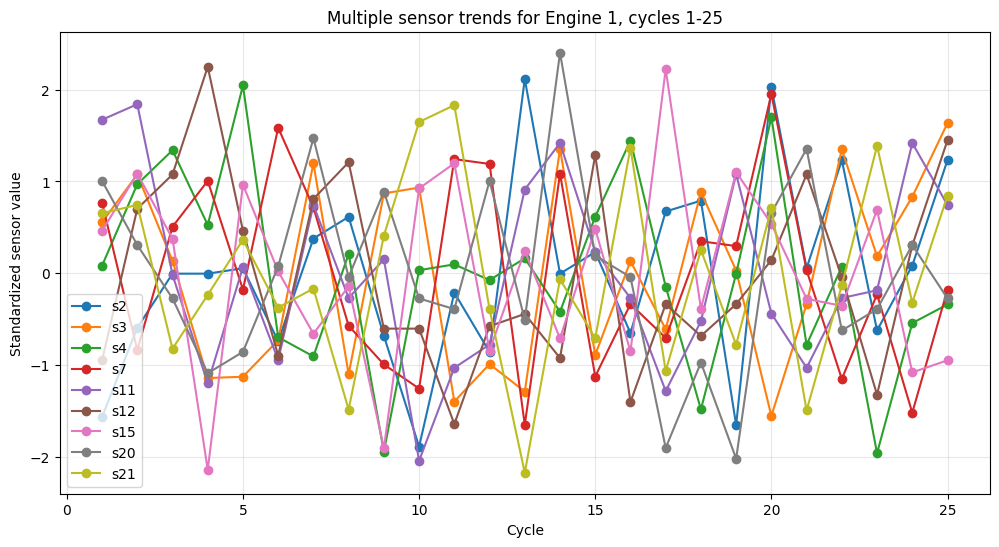

In [48]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

engine_id = 1
cycle_start = 1
cycle_end = 25

sensors_to_plot = ["s2", "s3", "s4", "s7", "s11", "s12", "s15", "s20", "s21"]

temp = train_df[
    (train_df["unit"] == engine_id) &
    (train_df["cycle"] >= cycle_start) &
    (train_df["cycle"] <= cycle_end)
].copy()

# Normalize sensors only for visualization
scaler = StandardScaler()
temp_scaled = temp.copy()
temp_scaled[sensors_to_plot] = scaler.fit_transform(temp[sensors_to_plot])

plt.figure(figsize=(12, 6))

for sensor in sensors_to_plot:
    plt.plot(
        temp_scaled["cycle"],
        temp_scaled[sensor],
        marker="o",
        label=sensor
    )

plt.xlabel("Cycle")
plt.ylabel("Standardized sensor value")
plt.title(f"Multiple sensor trends for Engine {engine_id}, cycles {cycle_start}-{cycle_end}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Visualization 4: Healthy vs near-failure sensor behavior

Compare early cycles and near-failure cycles.

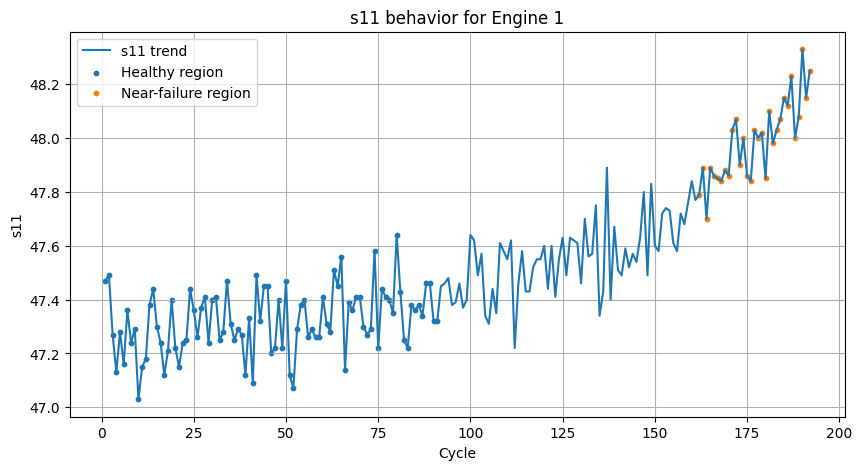

In [ ]:
engine_id = 1
engine_data = train_df[train_df["unit"] == engine_id]

healthy_part = engine_data[engine_data["RUL"] > 100]
fault_part = engine_data[engine_data["RUL"] <= 30]

sensor = "s11"

plt.figure(figsize=(10, 5))
plt.plot(engine_data["cycle"], engine_data[sensor], label=f"{sensor} trend")
plt.scatter(healthy_part["cycle"], healthy_part[sensor], label="Healthy region", s=10)
plt.scatter(fault_part["cycle"], fault_part[sensor], label="Near-failure region", s=10)

plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.title(f"{sensor} behavior for Engine {engine_id}")
plt.legend()
plt.grid(True)
plt.show()

Visualization 5: Early fault class imbalance

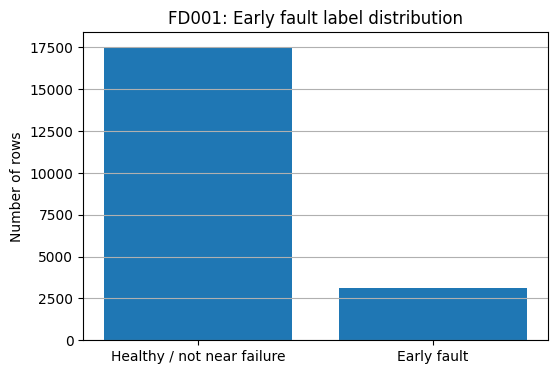

early_fault
0    17531
1     3100
Name: count, dtype: int64
Fault ratio: 0.15025931850128446


In [ ]:
fault_counts = train_df["early_fault"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Healthy / not near failure", "Early fault"], fault_counts.values)
plt.ylabel("Number of rows")
plt.title("FD001: Early fault label distribution")
plt.grid(axis="y")
plt.show()

print(fault_counts)
print("Fault ratio:", train_df["early_fault"].mean())

Visualization 6: Sensor correlation heatmap

This helps you see relationships among sensors.

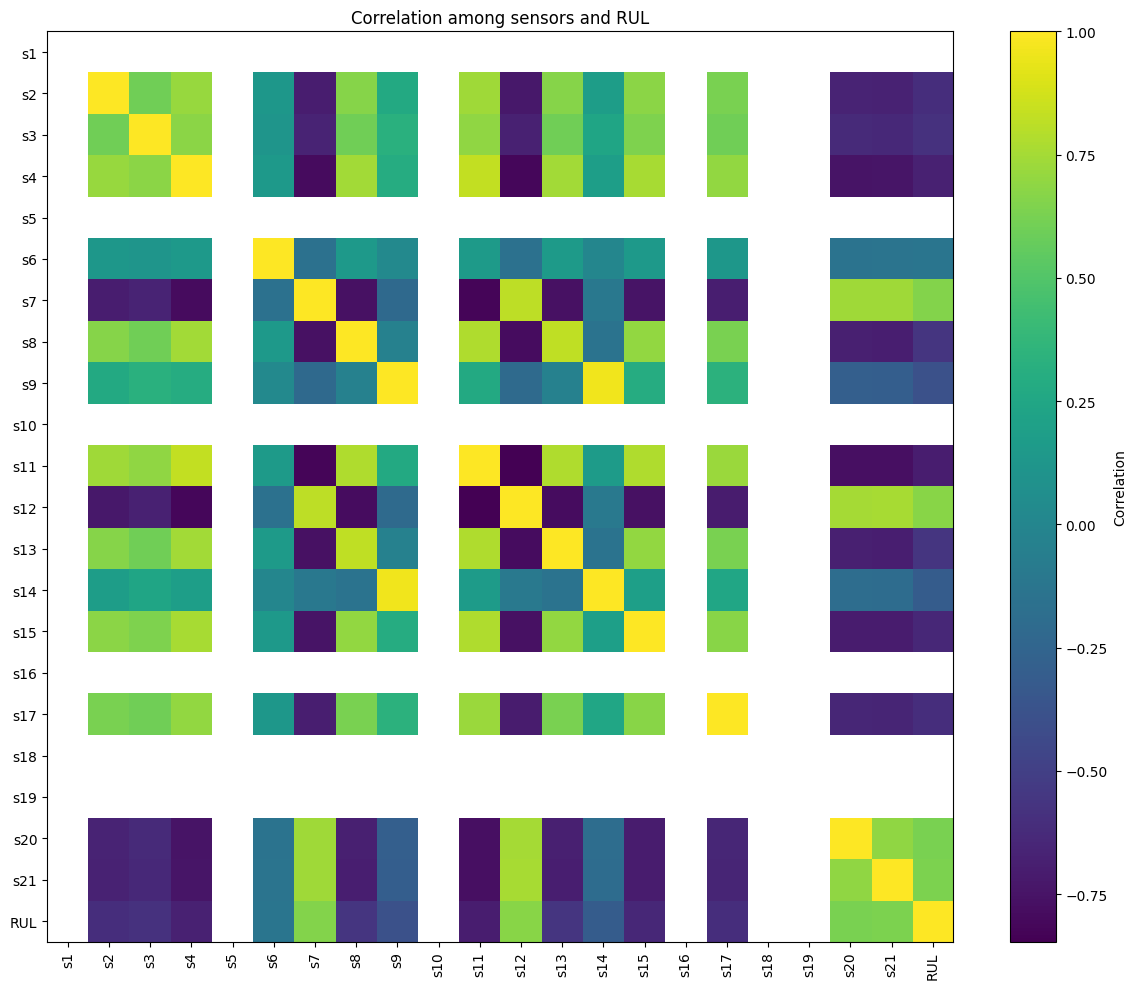

In [ ]:
sensor_cols = [f"s{i}" for i in range(1, 22)]

corr = train_df[sensor_cols + ["RUL"]].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation among sensors and RUL")
plt.tight_layout()
plt.show()

Visualization 7: RUL distribution

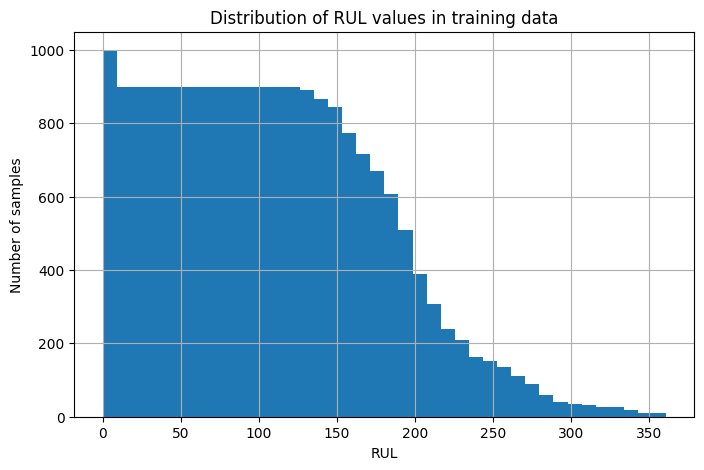

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(train_df["RUL"], bins=40)
plt.xlabel("RUL")
plt.ylabel("Number of samples")
plt.title("Distribution of RUL values in training data")
plt.grid(True)
plt.show()

In [ ]:
# Number of engines
num_train_engines = train_df["unit"].nunique()
num_test_engines = test_df["unit"].nunique()

print("Number of training engines:", num_train_engines)
print("Number of test engines:", num_test_engines)

# Lifecycle = maximum cycle for each engine
engine_lifecycle = train_df.groupby("unit")["cycle"].max().reset_index()
engine_lifecycle.columns = ["engine_id", "lifecycle_cycles"]

display(engine_lifecycle.head())

print("\nLifecycle summary:")
display(engine_lifecycle["lifecycle_cycles"].describe())

Number of training engines: 100
Number of test engines: 100


,engine_id,lifecycle_cycles
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269



Lifecycle summary:


,lifecycle_cycles
count,100.000000
mean,206.310000
std,46.342749
min,128.000000
25%,177.000000
50%,199.000000
75%,229.250000
max,362.000000


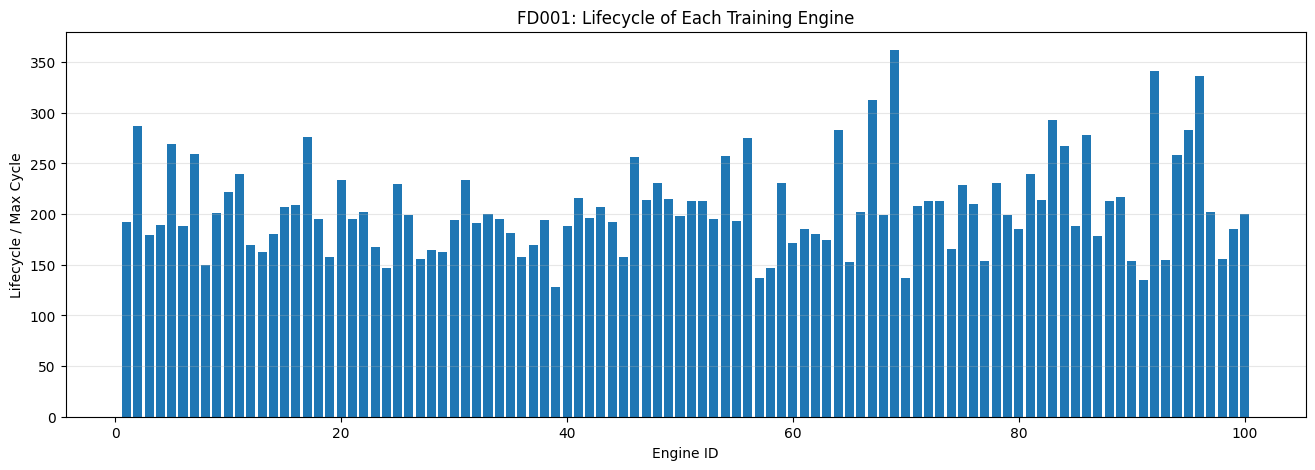

In [ ]:
plt.figure(figsize=(16, 5))
plt.bar(engine_lifecycle["engine_id"], engine_lifecycle["lifecycle_cycles"])

plt.xlabel("Engine ID")
plt.ylabel("Lifecycle / Max Cycle")
plt.title("FD001: Lifecycle of Each Training Engine")
plt.grid(axis="y", alpha=0.3)
plt.show()

Visualize operating conditions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

setting_cols = ["setting_1", "setting_2", "setting_3"]

rounded_settings_1dec = train_df[setting_cols].round(1)

print("Approximate unique operating settings after rounding to 1 decimal:")
print(rounded_settings_1dec.drop_duplicates().shape[0])

display(rounded_settings_1dec.drop_duplicates())

Approximate unique operating settings after rounding to 1 decimal:
1


,setting_1,setting_2,setting_3
0,-0.0,-0.0,100.0


In [ ]:
rounded_settings = train_df[setting_cols].round(2)

print("Number of approximate unique operating settings:")
print(rounded_settings.drop_duplicates().shape[0])

display(rounded_settings.drop_duplicates().head(20))

Number of approximate unique operating settings:
3


,setting_1,setting_2,setting_3
0,-0.00,-0.0,100.0
187,-0.01,0.0,100.0
216,0.01,0.0,100.0


Descriptive statistics per FD

In [49]:
print("=" * 60)
print("Comparative Statistics Across All FD Subsets")
print("=" * 60)

summary_rows = []

for fd in ["FD001", "FD002", "FD003", "FD004"]:
    DATA_DIR = f"{BASE_DIR}/{fd}"

    columns = (
        ["unit", "cycle"]
        + ["setting_1", "setting_2", "setting_3"]
        + [f"s{i}" for i in range(1, 22)]
    )

    df = pd.read_csv(
        f"{DATA_DIR}/train_{fd}.txt",
        sep=r"\s+",
        header=None,
        names=columns
    )

    rul_df = pd.read_csv(
        f"{DATA_DIR}/RUL_{fd}.txt",
        sep=r"\s+",
        header=None,
        names=["RUL"]
    )

    # Add RUL and early fault label
    df["max_cycle"] = df.groupby("unit")["cycle"].transform("max")
    df["RUL"] = df["max_cycle"] - df["cycle"]
    df["early_fault"] = (df["RUL"] <= 30).astype(int)

    # Engine lifecycle statistics
    engine_life = df.groupby("unit")["cycle"].max()

    summary_rows.append({
        "Dataset": fd,
        "Train engines": df["unit"].nunique(),
        "Total cycles": len(df),
        "Avg lifecycle": round(engine_life.mean(), 1),
        "Min lifecycle": engine_life.min(),
        "Max lifecycle": engine_life.max(),
        "Fault ratio": round(df["early_fault"].mean(), 4),
        "Avg RUL": round(df["RUL"].mean(), 1),
        "Std RUL": round(df["RUL"].std(), 1),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Dataset")

print(summary_df.to_string())

# Save result
summary_df.to_csv(f"{BASE_DIR}/dataset_summary.csv")
print("✓ Saved dataset_summary.csv")

Comparative Statistics Across All FD Subsets
         Train engines  Total cycles  Avg lifecycle  Min lifecycle  Max lifecycle  Fault ratio  Avg RUL  Std RUL
Dataset                                                                                                         
FD001              100         20631          206.3            128            362       0.1503    107.8     68.9
FD002              260         53759          206.8            128            378       0.1499    108.2     69.2
FD003              100         24720          247.2            145            525       0.1254    138.1     98.8
FD004              249         61249          246.0            128            543       0.1260    133.3     89.8
✓ Saved dataset_summary.csv


Sensor variance analysis

Which sensors change a lot during engine operation, and which sensors stay almost constant?

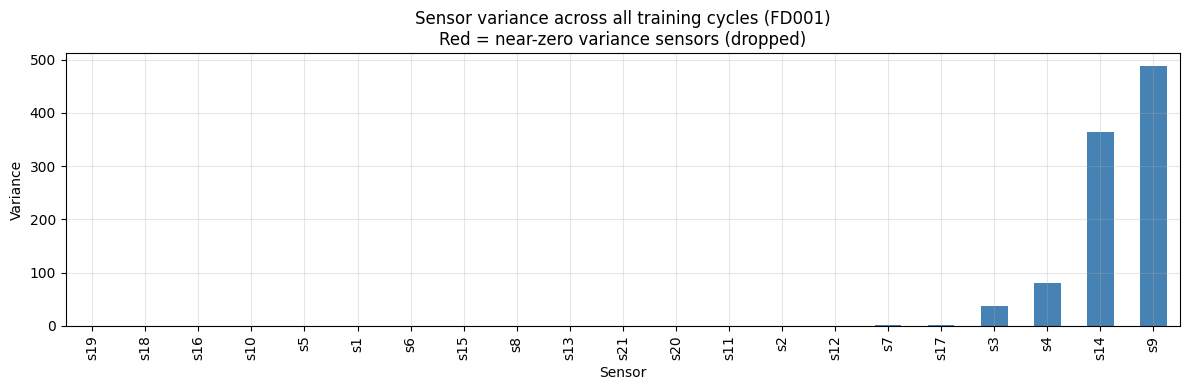

In [50]:
sensor_cols = [f"s{i}" for i in range(1, 22)]

fig, ax = plt.subplots(figsize=(12, 4))
variances = train_df[sensor_cols].var().sort_values()
colors    = ["red" if s in ["s1","s5","s10","s16","s18","s19"]
             else "steelblue" for s in variances.index]
variances.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Sensor variance across all training cycles (FD001)\n"
             "Red = near-zero variance sensors (dropped)")
ax.set_xlabel("Sensor"); ax.set_ylabel("Variance")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/sensor_variance.png", dpi=150, bbox_inches="tight")
plt.show()

Sensor-RUL correlation

Correlation	Meaning

close to +1	sensor value increases when RUL increases

close to -1	sensor value increases when RUL decreases

close to 0	weak linear relation with RUL


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


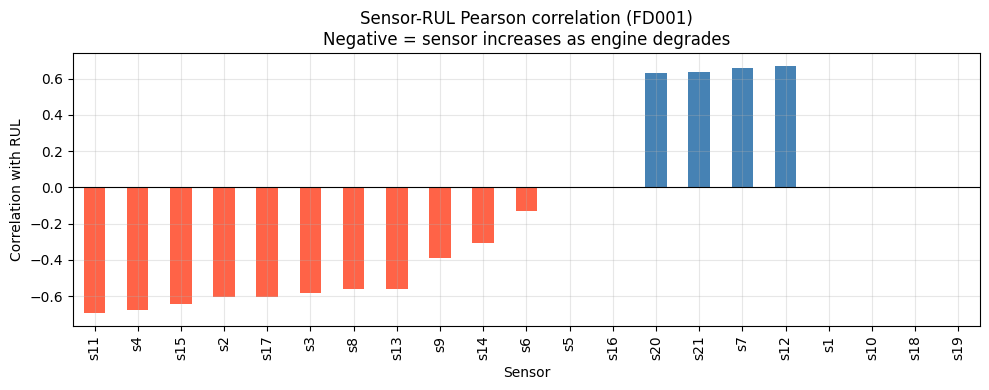

In [51]:
sensor_cols = [f"s{i}" for i in range(1, 22)]
correlations = train_df[sensor_cols].corrwith(train_df["RUL"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["tomato" if c < 0 else "steelblue" for c in correlations]
correlations.plot(kind="bar", ax=ax, color=colors)
ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_title("Sensor-RUL Pearson correlation (FD001)\n"
             "Negative = sensor increases as engine degrades")
ax.set_xlabel("Sensor"); ax.set_ylabel("Correlation with RUL")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/sensor_rul_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

Cross-FD fault ratio comparison

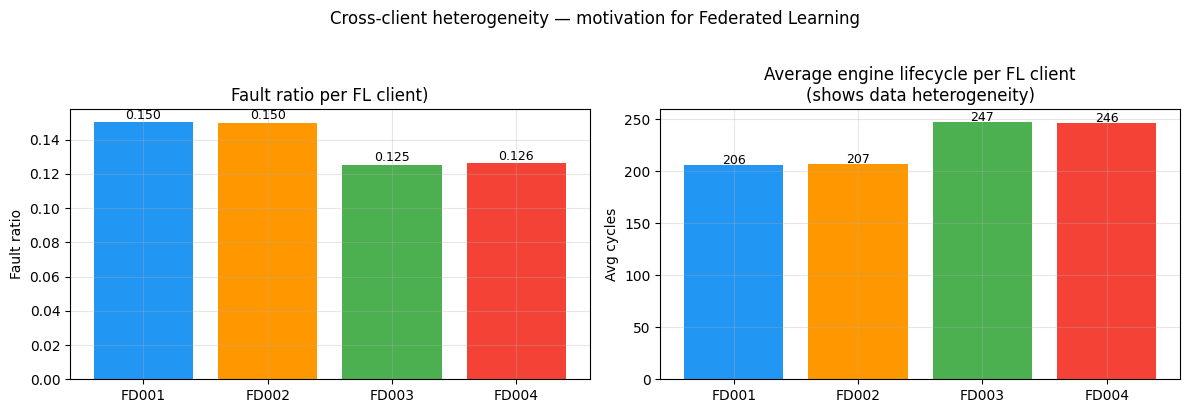

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fd_names    = []
fault_ratios = []
avg_lifecycles = []

for fd in ["FD001", "FD002", "FD003", "FD004"]:
    DATA_DIR = f"{BASE_DIR}/{fd}"
    columns  = (["unit", "cycle"]
                + ["setting_1", "setting_2", "setting_3"]
                + [f"s{i}" for i in range(1, 22)])
    df = pd.read_csv(f"{DATA_DIR}/train_{fd}.txt",
                     sep=r"\s+", header=None, names=columns)
    df["max_cycle"]   = df.groupby("unit")["cycle"].transform("max")
    df["RUL"]         = df["max_cycle"] - df["cycle"]
    df["early_fault"] = (df["RUL"] <= 30).astype(int)
    fd_names.append(fd)
    fault_ratios.append(df["early_fault"].mean())
    avg_lifecycles.append(df.groupby("unit")["cycle"].max().mean())

axes[0].bar(fd_names, fault_ratios, color=["#2196F3","#FF9800","#4CAF50","#F44336"])
axes[0].set_title("Fault ratio per FL client)")
axes[0].set_ylabel("Fault ratio"); axes[0].grid(alpha=0.3)
for i, v in enumerate(fault_ratios):
    axes[0].text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)

axes[1].bar(fd_names, avg_lifecycles, color=["#2196F3","#FF9800","#4CAF50","#F44336"])
axes[1].set_title("Average engine lifecycle per FL client\n(shows data heterogeneity)")
axes[1].set_ylabel("Avg cycles"); axes[1].grid(alpha=0.3)
for i, v in enumerate(avg_lifecycles):
    axes[1].text(i, v + 1, f"{v:.0f}", ha="center", fontsize=9)

plt.suptitle("Cross-client heterogeneity — motivation for Federated Learning", y=1.02)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/cross_fd_comparison.png", dpi=150, bbox_inches="tight")
plt.show()